# Actividad 1: Modelos no lineales

- Alex Rubiño Fernández
- Aprendizaje Automático 2
- 06/04/2026
- UNIR

### Ejercicio 1: Genera y visualiza el dataset sintético.

Generamos un dataset sintético con las siguientes características: dos clases que forman dos lunas intercaladas, una tercera clase con distribución gaussiana y solapamiento entre todas las clases. Por último, visualizamos el dataset resultante.

Para ello, usamos make_moons para crear las dos lunas, con 300 muestras y un nivel de ruido de 0.2. Para la tercera clase, empleamos make_blobs generando 200 muestras alrededor del centro (0, 0.5) con una desviación estándar de 0.4. Después combinamos ambos conjuntos y mostramos los datos en un gráfico de dispersión, asignando un color diferente a cada clase. Finalmente, dividimos el dataset en entrenamiento (70%) y prueba (30%), manteniendo la proporción original de las clases.

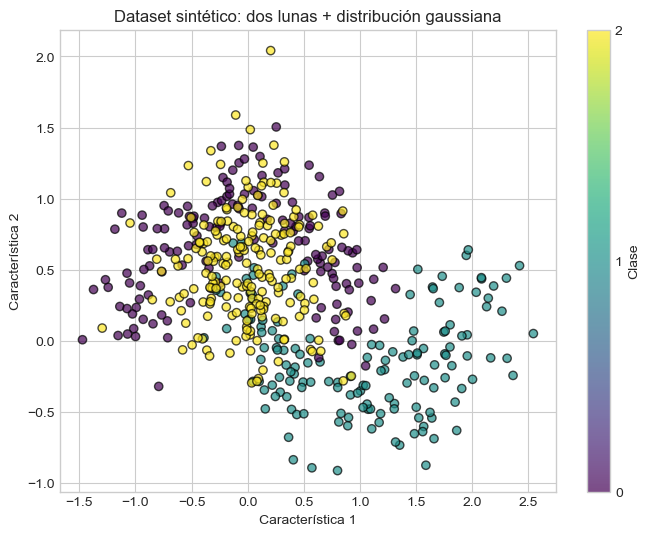

Tamaño del dataset total: 500 muestras
Tamaño entrenamiento: 350, prueba: 150
Distribución de clases en entrenamiento: [105 105 140]
Distribución de clases en prueba: [45 45 60]


In [6]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split
import seaborn as sns

# Configuración para visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Generamos dos lunas intercaladas (clase 0 y 1)
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

# Generamos una tercera clase con distribución gaussiana alrededor del centro
X_gauss, y_gauss = make_blobs(n_samples=200, centers=[[0, 0.5]], cluster_std=0.4, random_state=42)
y_gauss = np.full(len(X_gauss), 2)  # Asignar clase 2

# Combinamos los datasets
X = np.vstack([X_moons, X_gauss])
y = np.hstack([y_moons, y_gauss])

# Visualizamos el dataset
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', alpha=0.7)
plt.colorbar(scatter, ticks=[0, 1, 2], label='Clase')
plt.title('Dataset sintético: dos lunas + distribución gaussiana')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamaño del dataset total: {X.shape[0]} muestras")
print(f"Tamaño entrenamiento: {X_train.shape[0]}, prueba: {X_test.shape[0]}")
print(f"Distribución de clases en entrenamiento: {np.bincount(y_train)}")
print(f"Distribución de clases en prueba: {np.bincount(y_test)}")